In [1]:
%pip install -U ultralytics opencv-python matplotlib kagglehub scikit-learn pyyaml pillow -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.


In [3]:
from ultralytics import YOLO
import kagglehub
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import os
import json
import shutil
import time
from statistics import mean, stdev
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch

c:\Users\jandu\Documents\Capstone\Capstone-EdgeSafe\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
output_dir = Path.cwd() / "kaggle"

path = kagglehub.dataset_download(
    "abuzarkhaaan/helmetandguntesting",
    output_dir=str(output_dir)
)

dataset_path = Path(path) / "Gun with webcam views.v1i.yolov8"
print("Dataset path:", dataset_path)

Dataset path: c:\Users\jandu\Documents\Capstone\Capstone-EdgeSafe\ml\kaggle\Gun with webcam views.v1i.yolov8


In [5]:
print(list(dataset_path.iterdir()))
print((dataset_path / "data.yaml").exists())
print((dataset_path / "train" / "images").exists())
print((dataset_path / "valid" / "images").exists())
print((dataset_path / "test" / "images").exists())

[WindowsPath('c:/Users/jandu/Documents/Capstone/Capstone-EdgeSafe/ml/kaggle/Gun with webcam views.v1i.yolov8/data.yaml'), WindowsPath('c:/Users/jandu/Documents/Capstone/Capstone-EdgeSafe/ml/kaggle/Gun with webcam views.v1i.yolov8/README.dataset.txt'), WindowsPath('c:/Users/jandu/Documents/Capstone/Capstone-EdgeSafe/ml/kaggle/Gun with webcam views.v1i.yolov8/README.roboflow.txt'), WindowsPath('c:/Users/jandu/Documents/Capstone/Capstone-EdgeSafe/ml/kaggle/Gun with webcam views.v1i.yolov8/test'), WindowsPath('c:/Users/jandu/Documents/Capstone/Capstone-EdgeSafe/ml/kaggle/Gun with webcam views.v1i.yolov8/train'), WindowsPath('c:/Users/jandu/Documents/Capstone/Capstone-EdgeSafe/ml/kaggle/Gun with webcam views.v1i.yolov8/valid')]
True
True
True
True


In [6]:
import yaml

yaml_path = dataset_path / "data.yaml"

with open(yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

print(data_config)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 1, 'names': ['Guns'], 'roboflow': {'workspace': 'projects-szgmu', 'project': 'gun-with-webcam-views-dbgmf', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/projects-szgmu/gun-with-webcam-views-dbgmf/dataset/1'}}


In [7]:
model_yolo = YOLO("yolo11n.pt")

In [8]:
EPOCHS = 100
IMG_SIZE = 640
BATCH_SIZE = 16
PATIENCE = 20
RUN_NAME = "yolo11n_firearm_v1"

In [9]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA GeForce RTX 3070


In [10]:
print(model_yolo)
print("ckpt_path:", getattr(model_yolo, "ckpt_path", None))


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

In [45]:
results = model_yolo.train(
    data=str(yaml_path),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    name=RUN_NAME,
    device=0,
    workers=4
)

Ultralytics 8.4.36  Python-3.12.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\jandu\Documents\Capstone\Capstone-EdgeSafe\ml\kaggle\Gun with webcam views.v1i.yolov8\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_firearm_v1, nbs=64, nm

In [11]:
from pathlib import Path
from ultralytics import YOLO

search_roots = [Path.cwd(), Path.cwd().parent]

best_model_path = None

for root in search_roots:
    matches = list(root.glob("**/best.pt"))
    if matches:
        print(f"Searching in: {root}")
        for m in matches:
            print("Found:", m)
        best_model_path = matches[0]
        break

if best_model_path is None:
    raise FileNotFoundError("No best.pt found from current directory or parent directory.")

print("\nUsing model:", best_model_path)
print("Exists:", best_model_path.exists())

best_model = YOLO(str(best_model_path))

Searching in: c:\Users\jandu\Documents\Capstone\Capstone-EdgeSafe
Found: c:\Users\jandu\Documents\Capstone\Capstone-EdgeSafe\runs\detect\yolo11n_firearm_v1\weights\best.pt

Using model: c:\Users\jandu\Documents\Capstone\Capstone-EdgeSafe\runs\detect\yolo11n_firearm_v1\weights\best.pt
Exists: True


In [12]:
best_model = YOLO(str(best_model_path))
metrics = best_model.val(data=str(yaml_path))

Ultralytics 8.4.36  Python-3.12.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 86.67.1 MB/s, size: 29.3 KB)
val: Scanning C:\Users\jandu\Documents\Capstone\Capstone-EdgeSafe\ml\kaggle\Gun with webcam views.v1i.yolov8\valid\labels.cache... 240 images, 104 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 240/240  0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 7, len(boxes) = 137. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 8.3it/s 1.8s<0.1s
                   all        240        137      0.901      0.663      0.722      0.413
Speed: 1.2ms preprocess, 2.8ms inference, 0.0ms loss, 0

In [13]:
mp = float(metrics.box.mp)
mr = float(metrics.box.mr)
map50 = float(metrics.box.map50)
map95 = float(metrics.box.map)

f1 = 2 * (mp * mr) / (mp + mr + 1e-6)

print("Mean Precision:", mp)
print("Mean Recall:", mr)
print("F1 Score:", f1)
print("mAP@0.5:", map50)
print("mAP@0.5:0.95:", map95)

results_dict = {
    "run_name": RUN_NAME,
    "precision_mean": mp,
    "recall_mean": mr,
    "f1_score": f1,
    "map_50": map50,
    "map_50_95": map95
}

Mean Precision: 0.9008898680548164
Mean Recall: 0.6634946477033912
F1 Score: 0.7641794169065566
mAP@0.5: 0.7218970648477481
mAP@0.5:0.95: 0.4127485505966778


In [14]:
from pathlib import Path
import json

output_dir = Path.cwd() / ".." / "runs" / "detect" / RUN_NAME
output_dir.mkdir(parents=True, exist_ok=True)
print("Output directory:", output_dir)
output_metrics = output_dir / "metrics_summary.json"

with open(output_metrics, "w") as f:
    json.dump(results_dict, f, indent=4)

print("Saved metrics to:", output_metrics)

Output directory: c:\Users\jandu\Documents\Capstone\Capstone-EdgeSafe\ml\..\runs\detect\yolo11n_firearm_v1
Saved metrics to: c:\Users\jandu\Documents\Capstone\Capstone-EdgeSafe\ml\..\runs\detect\yolo11n_firearm_v1\metrics_summary.json


In [15]:
test_img = dataset_path / "valid" / "images" / "gun_3_3_1__0003784_jpg.rf.8a25e5f44f10f30054058526ac6e89b4.jpg"

pred = best_model(str(test_img), conf=0.28)[0]


image 1/1 c:\Users\jandu\Documents\Capstone\Capstone-EdgeSafe\ml\kaggle\Gun with webcam views.v1i.yolov8\valid\images\gun_3_3_1__0003784_jpg.rf.8a25e5f44f10f30054058526ac6e89b4.jpg: 640x640 1 Guns, 31.8ms
Speed: 5.3ms preprocess, 31.8ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


In [16]:
detections = []

for box in pred.boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    cls_name = best_model.names[cls_id]

    detections.append({
        "box": [x1, y1, x2, y2],
        "class": cls_name,
        "confidence": conf
    })

print(detections)

[{'box': [501.7132873535156, 178.23797607421875, 636.3326416015625, 447.42474365234375], 'class': 'Guns', 'confidence': 0.7865773439407349}]


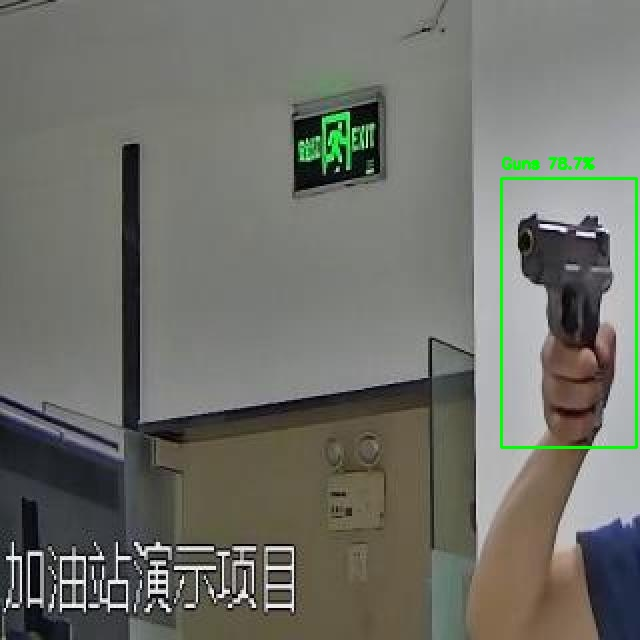

In [23]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import Image, display

def show_results_save(img_path, results, title="YOLO Detection", out_file="debug_detection.jpg"):
    img = cv2.imread(str(img_path))

    for result in results:
        x1, y1, x2, y2 = map(int, result["box"])
        cls_name = result["class"]
        conf = result["confidence"]

        label = f"{cls_name} {conf*100:.1f}%"
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            img,
            label,
            (x1, max(y1 - 10, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2
        )

    cv2.imwrite(out_file, img)
    display(Image(filename=out_file))

show_results_save(test_img, detections, "YOLO Firearm Detection")

..\runs\detect\yolo11n_firearm_v1


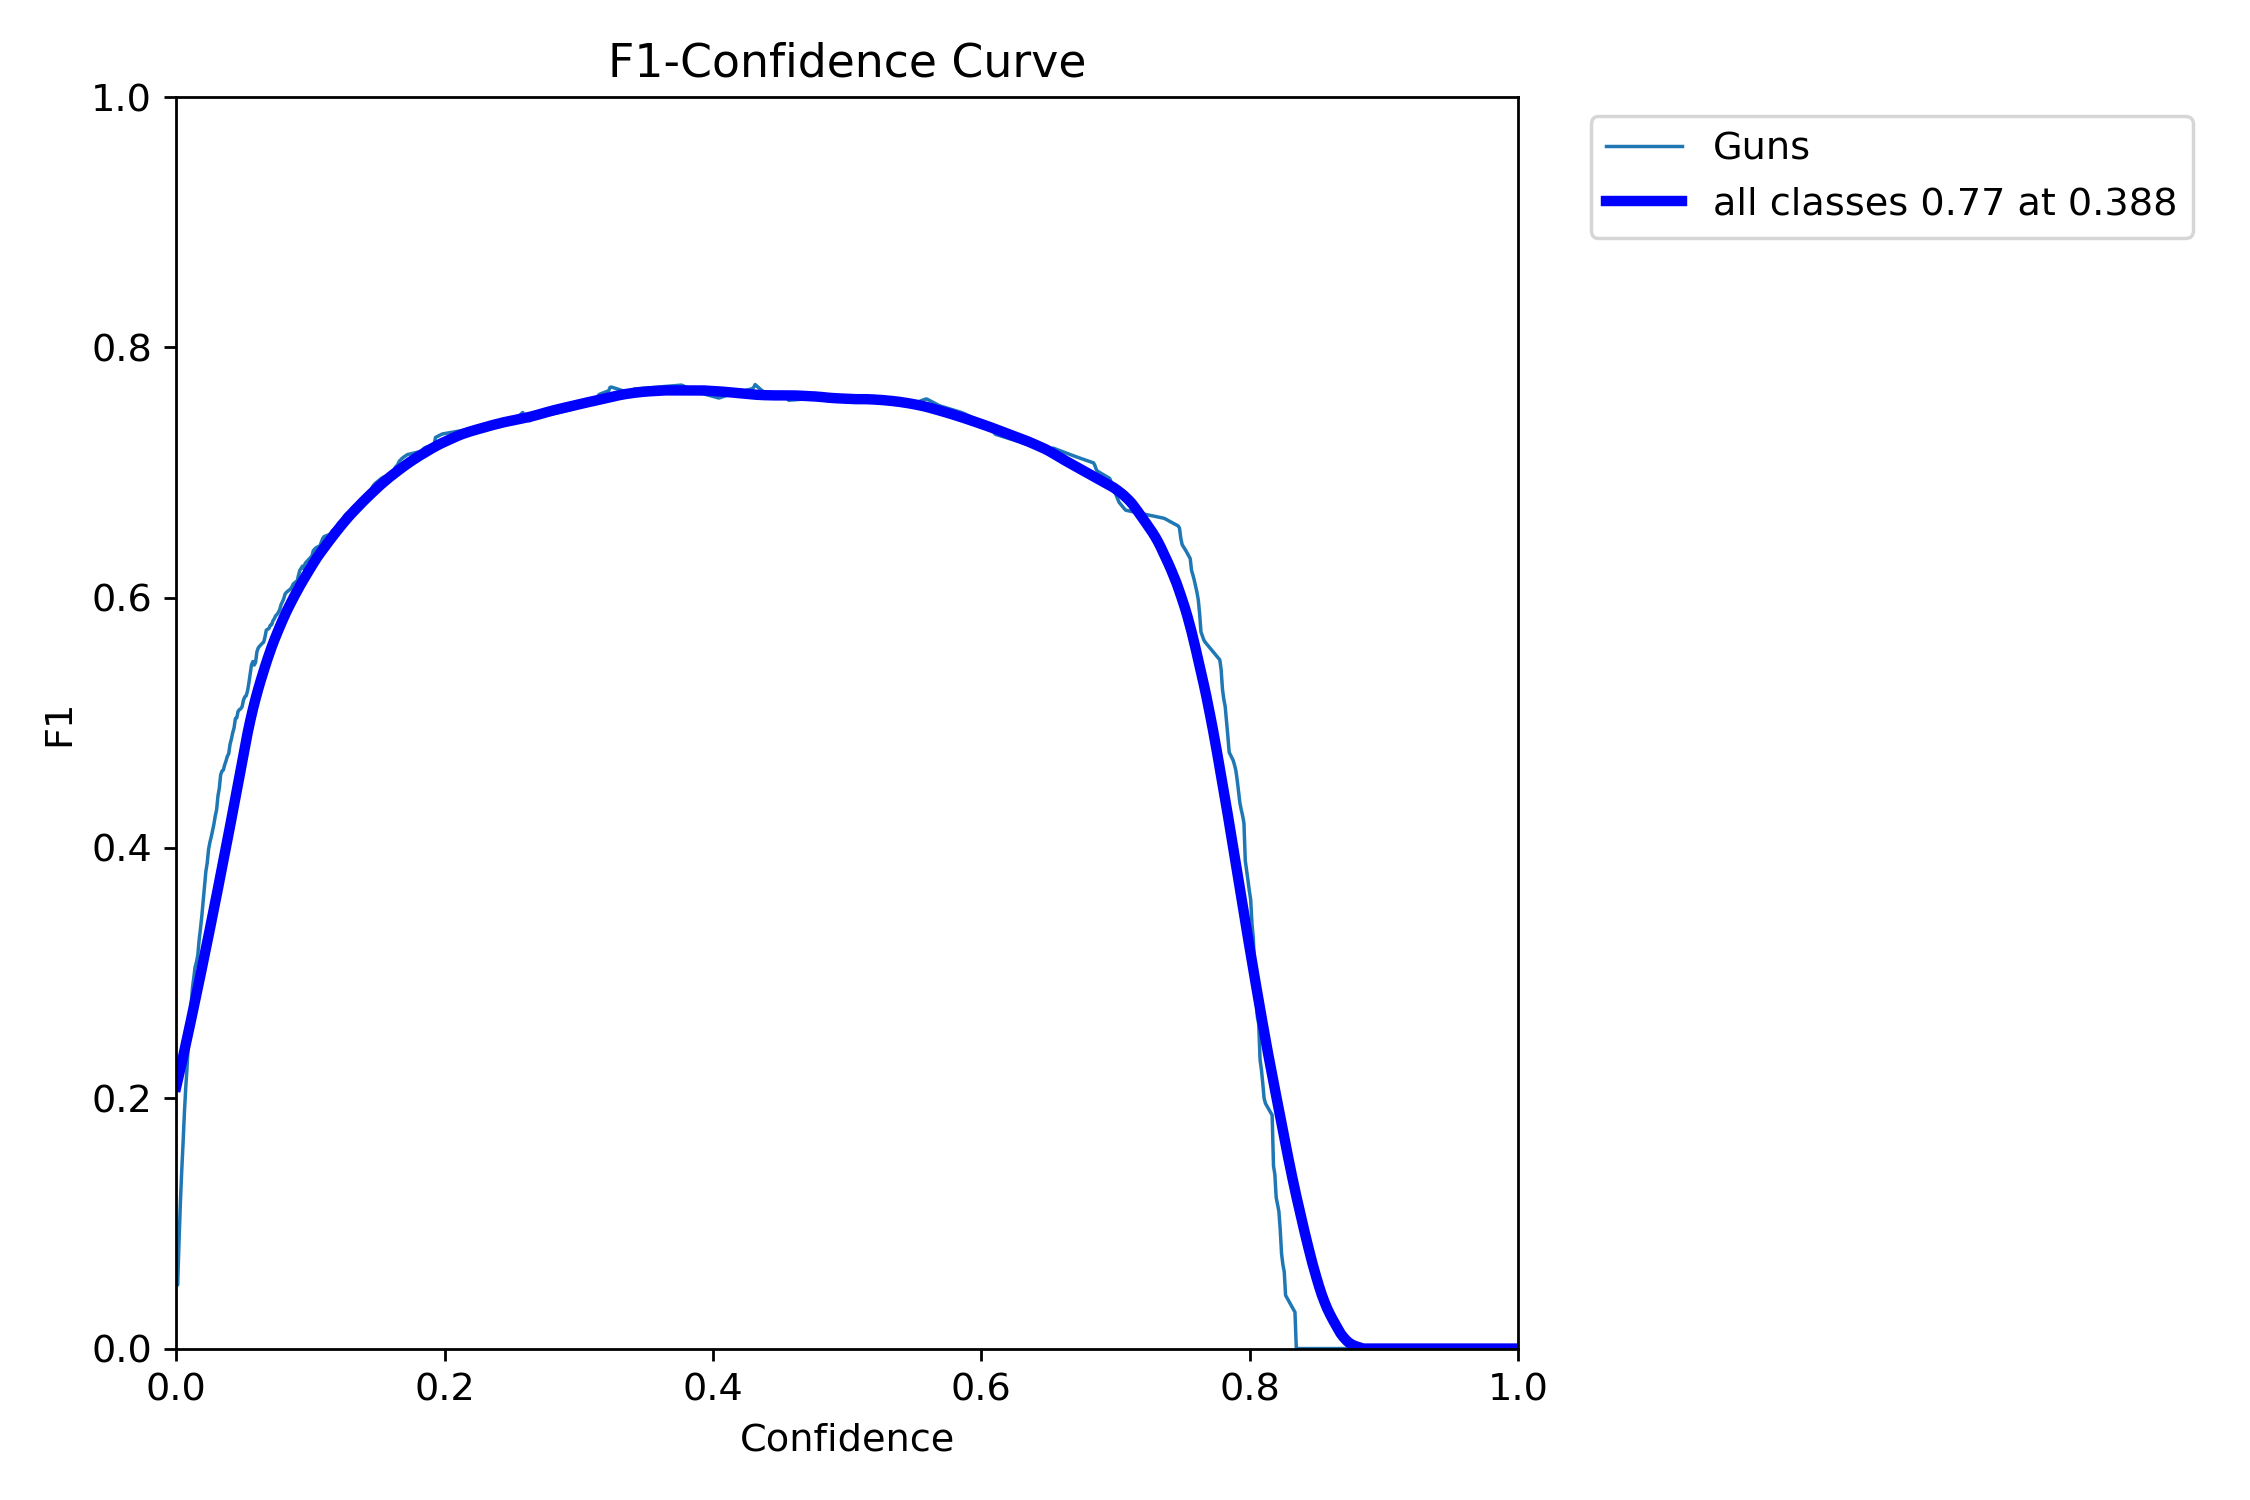

BoxF1_curve.png


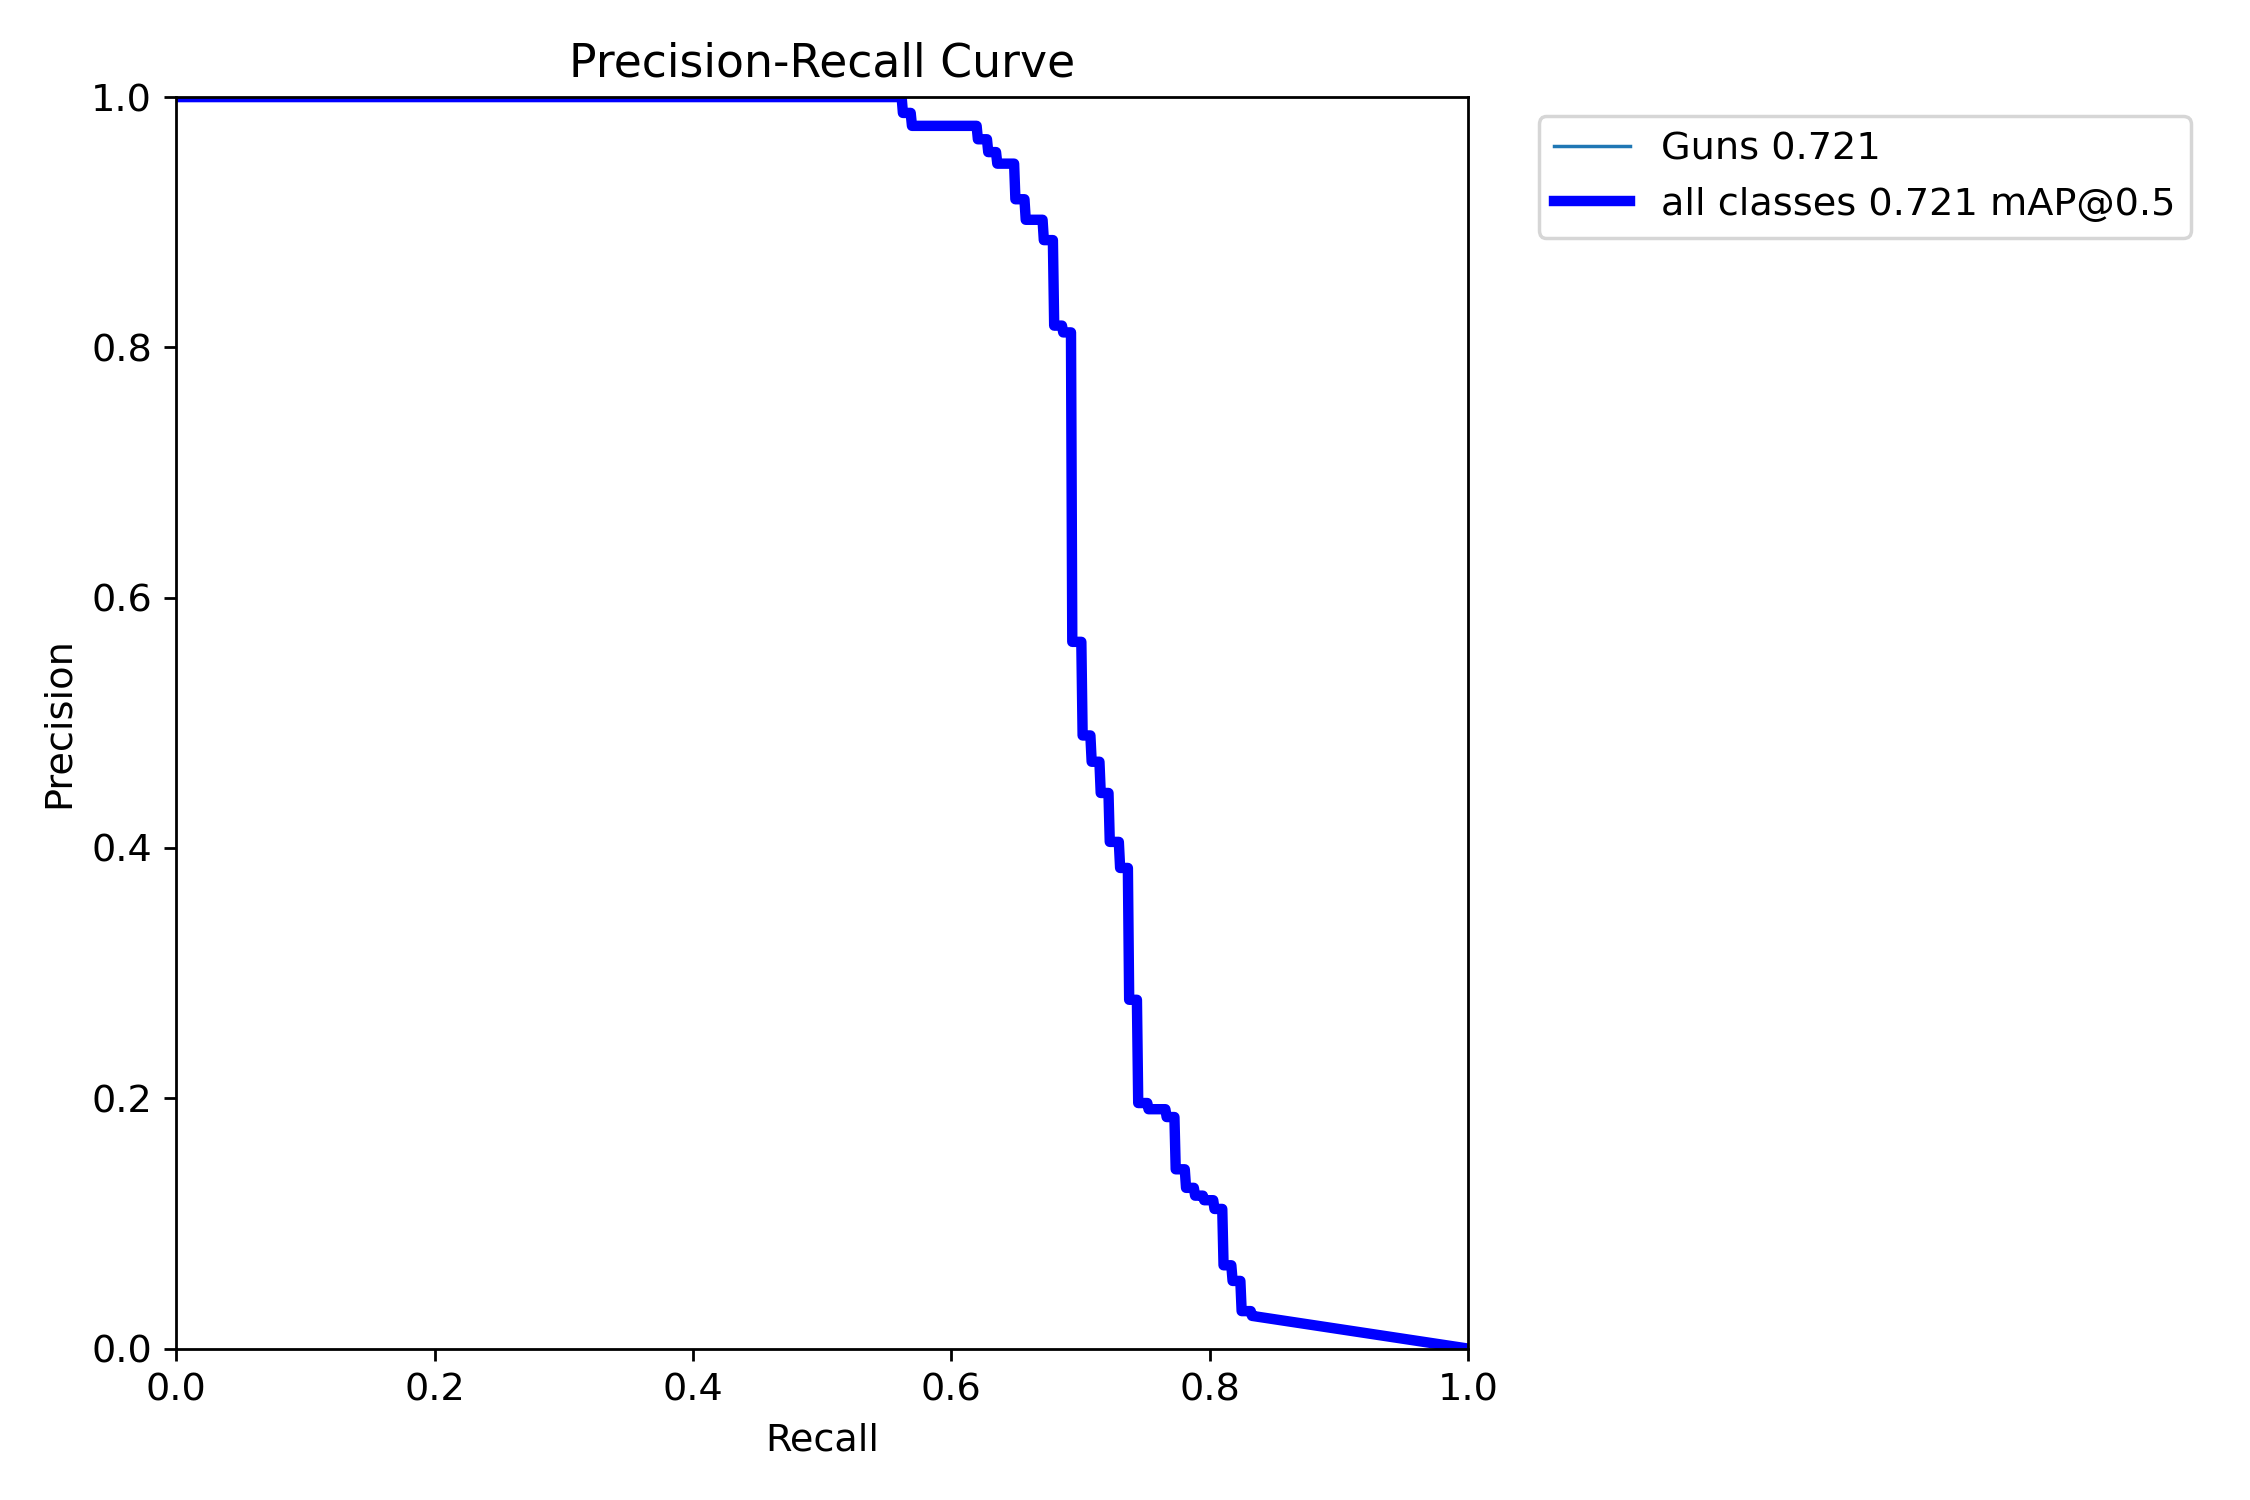

BoxPR_curve.png


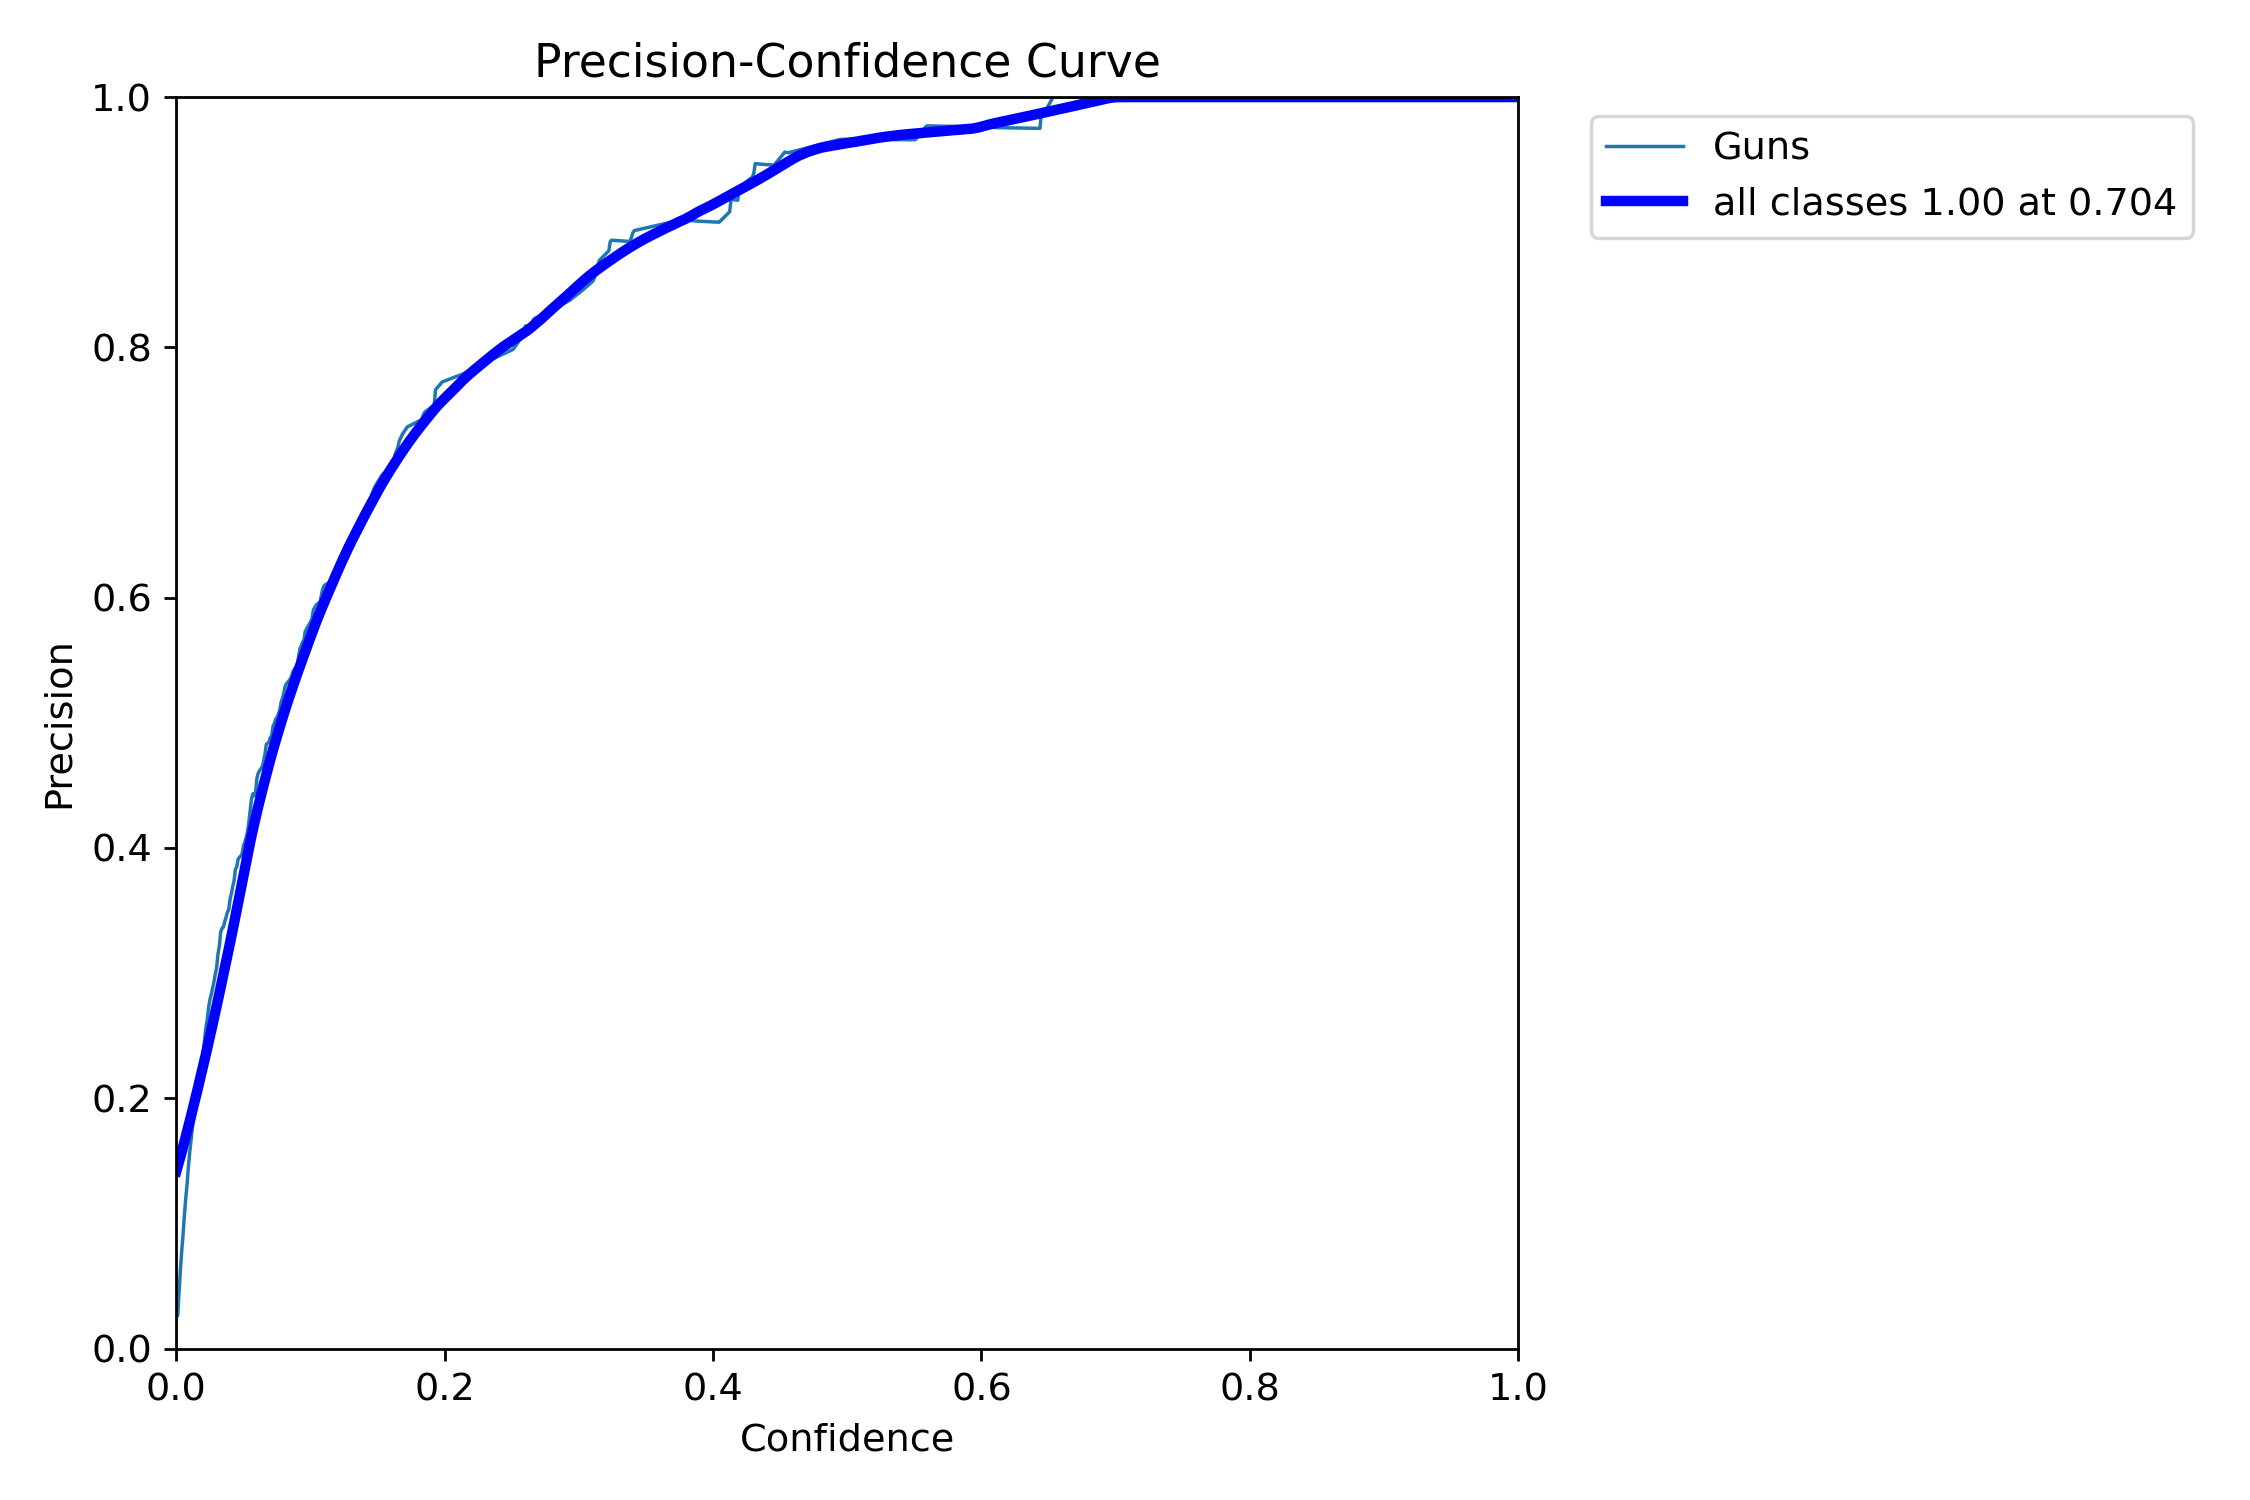

BoxP_curve.png


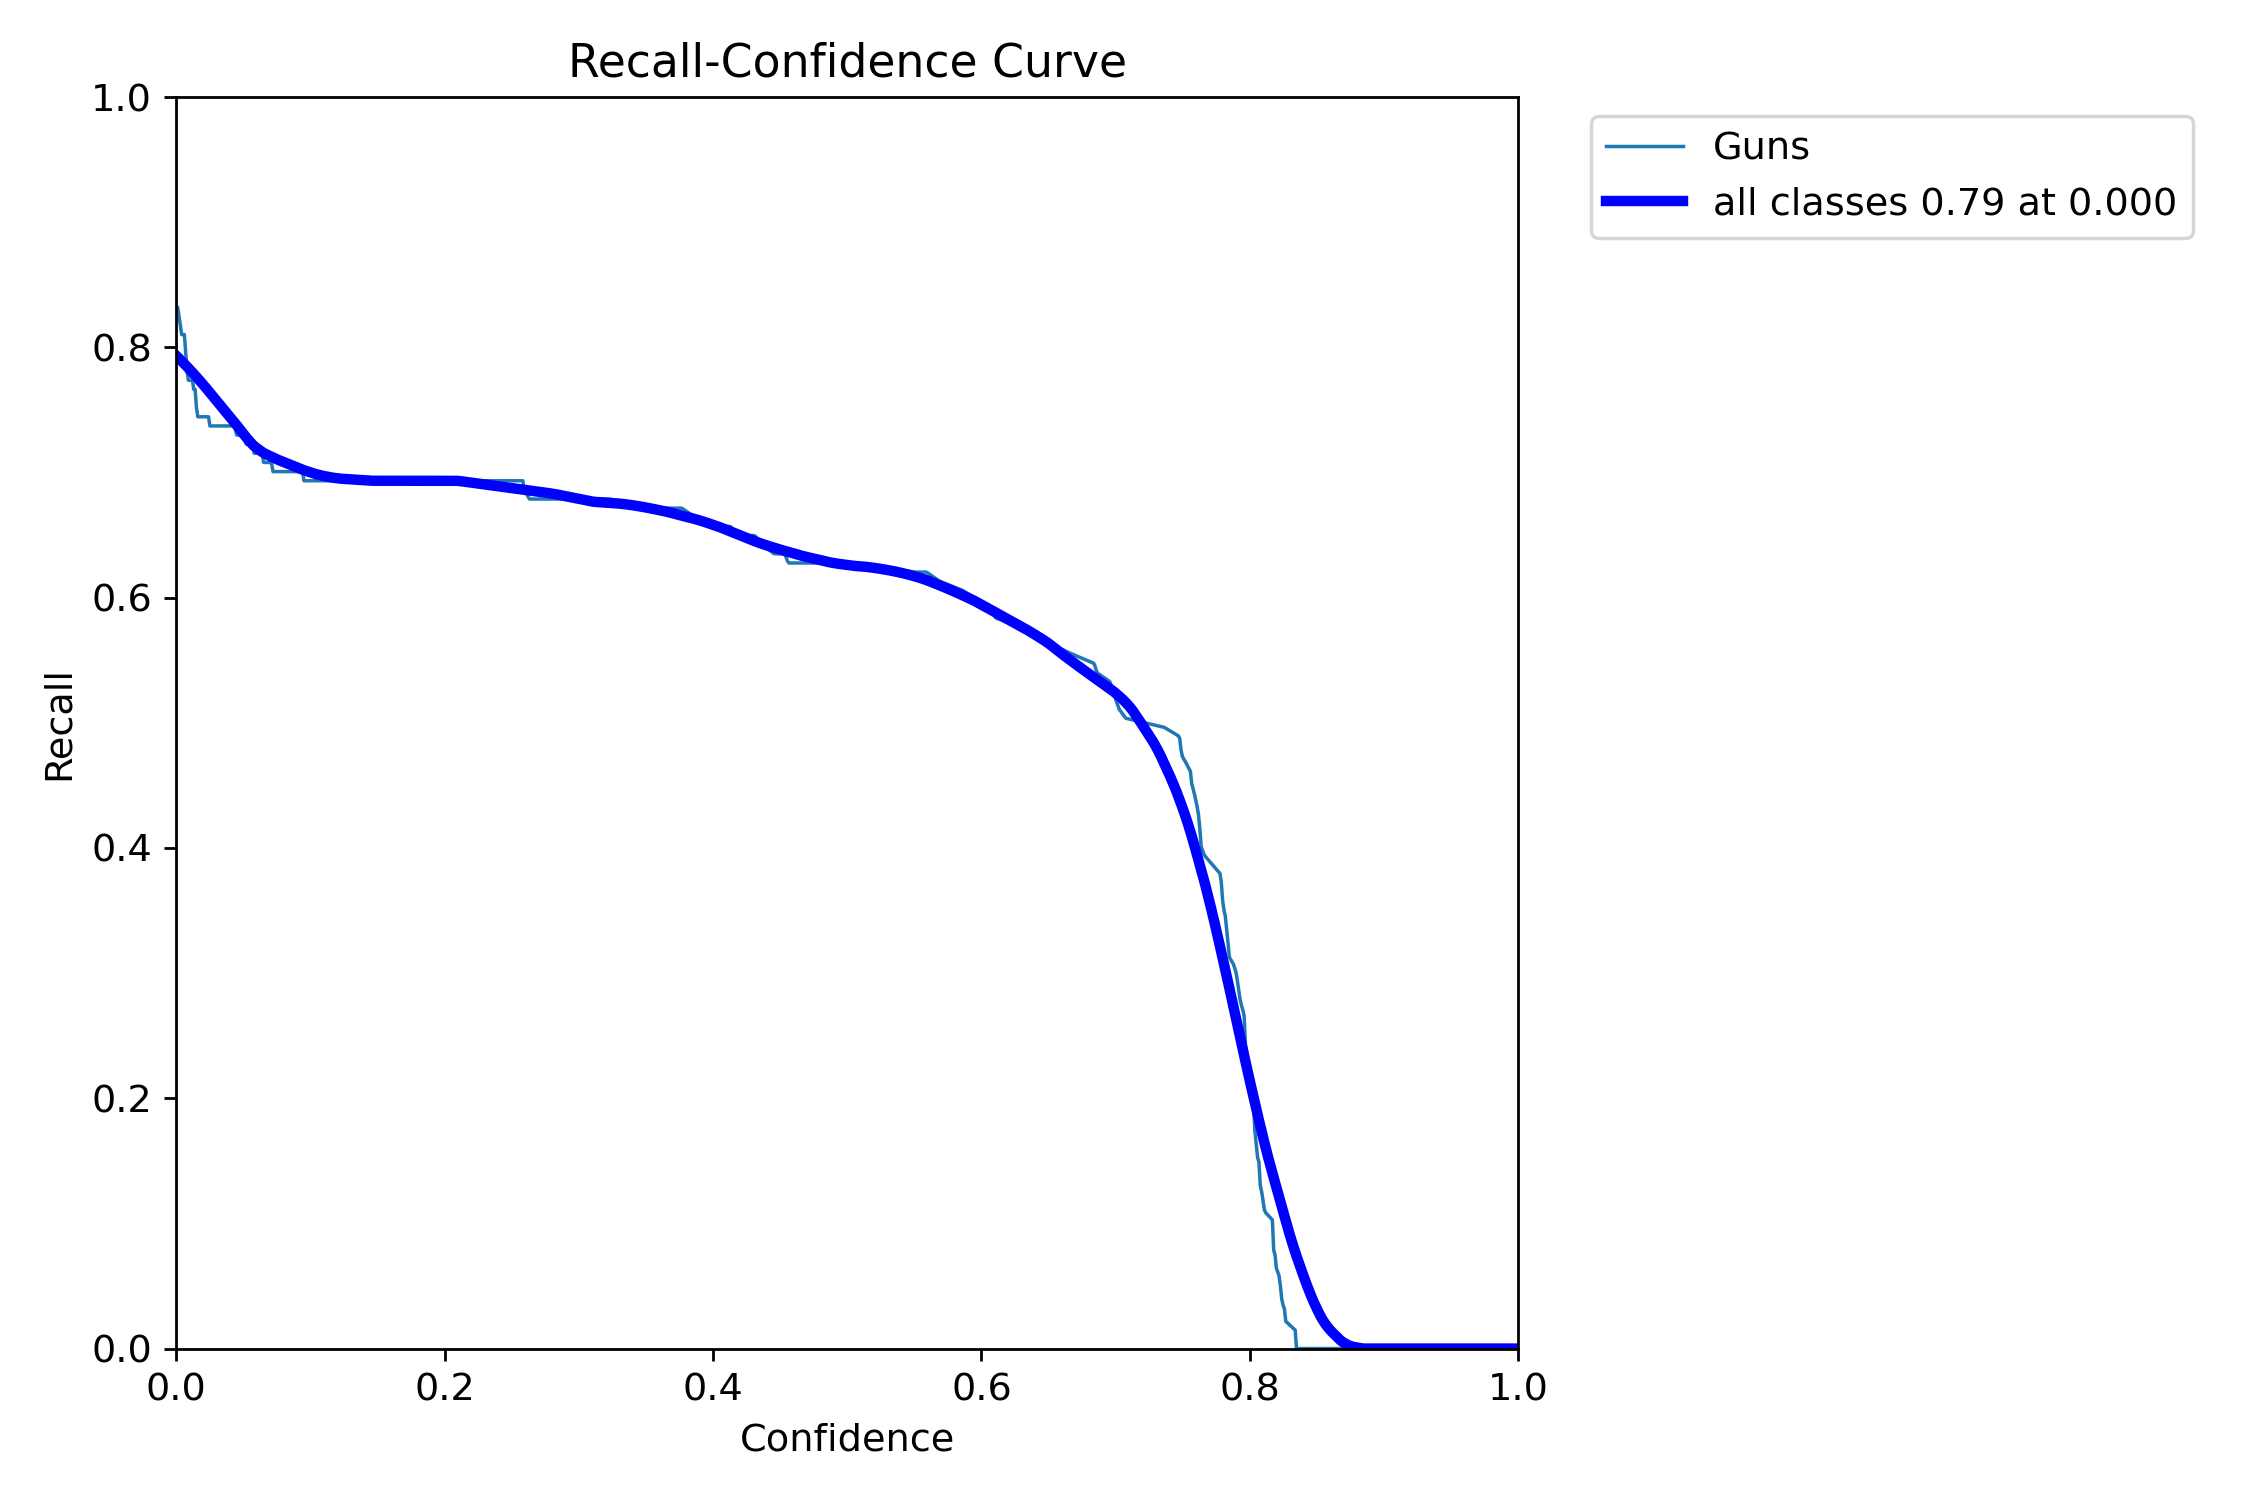

BoxR_curve.png


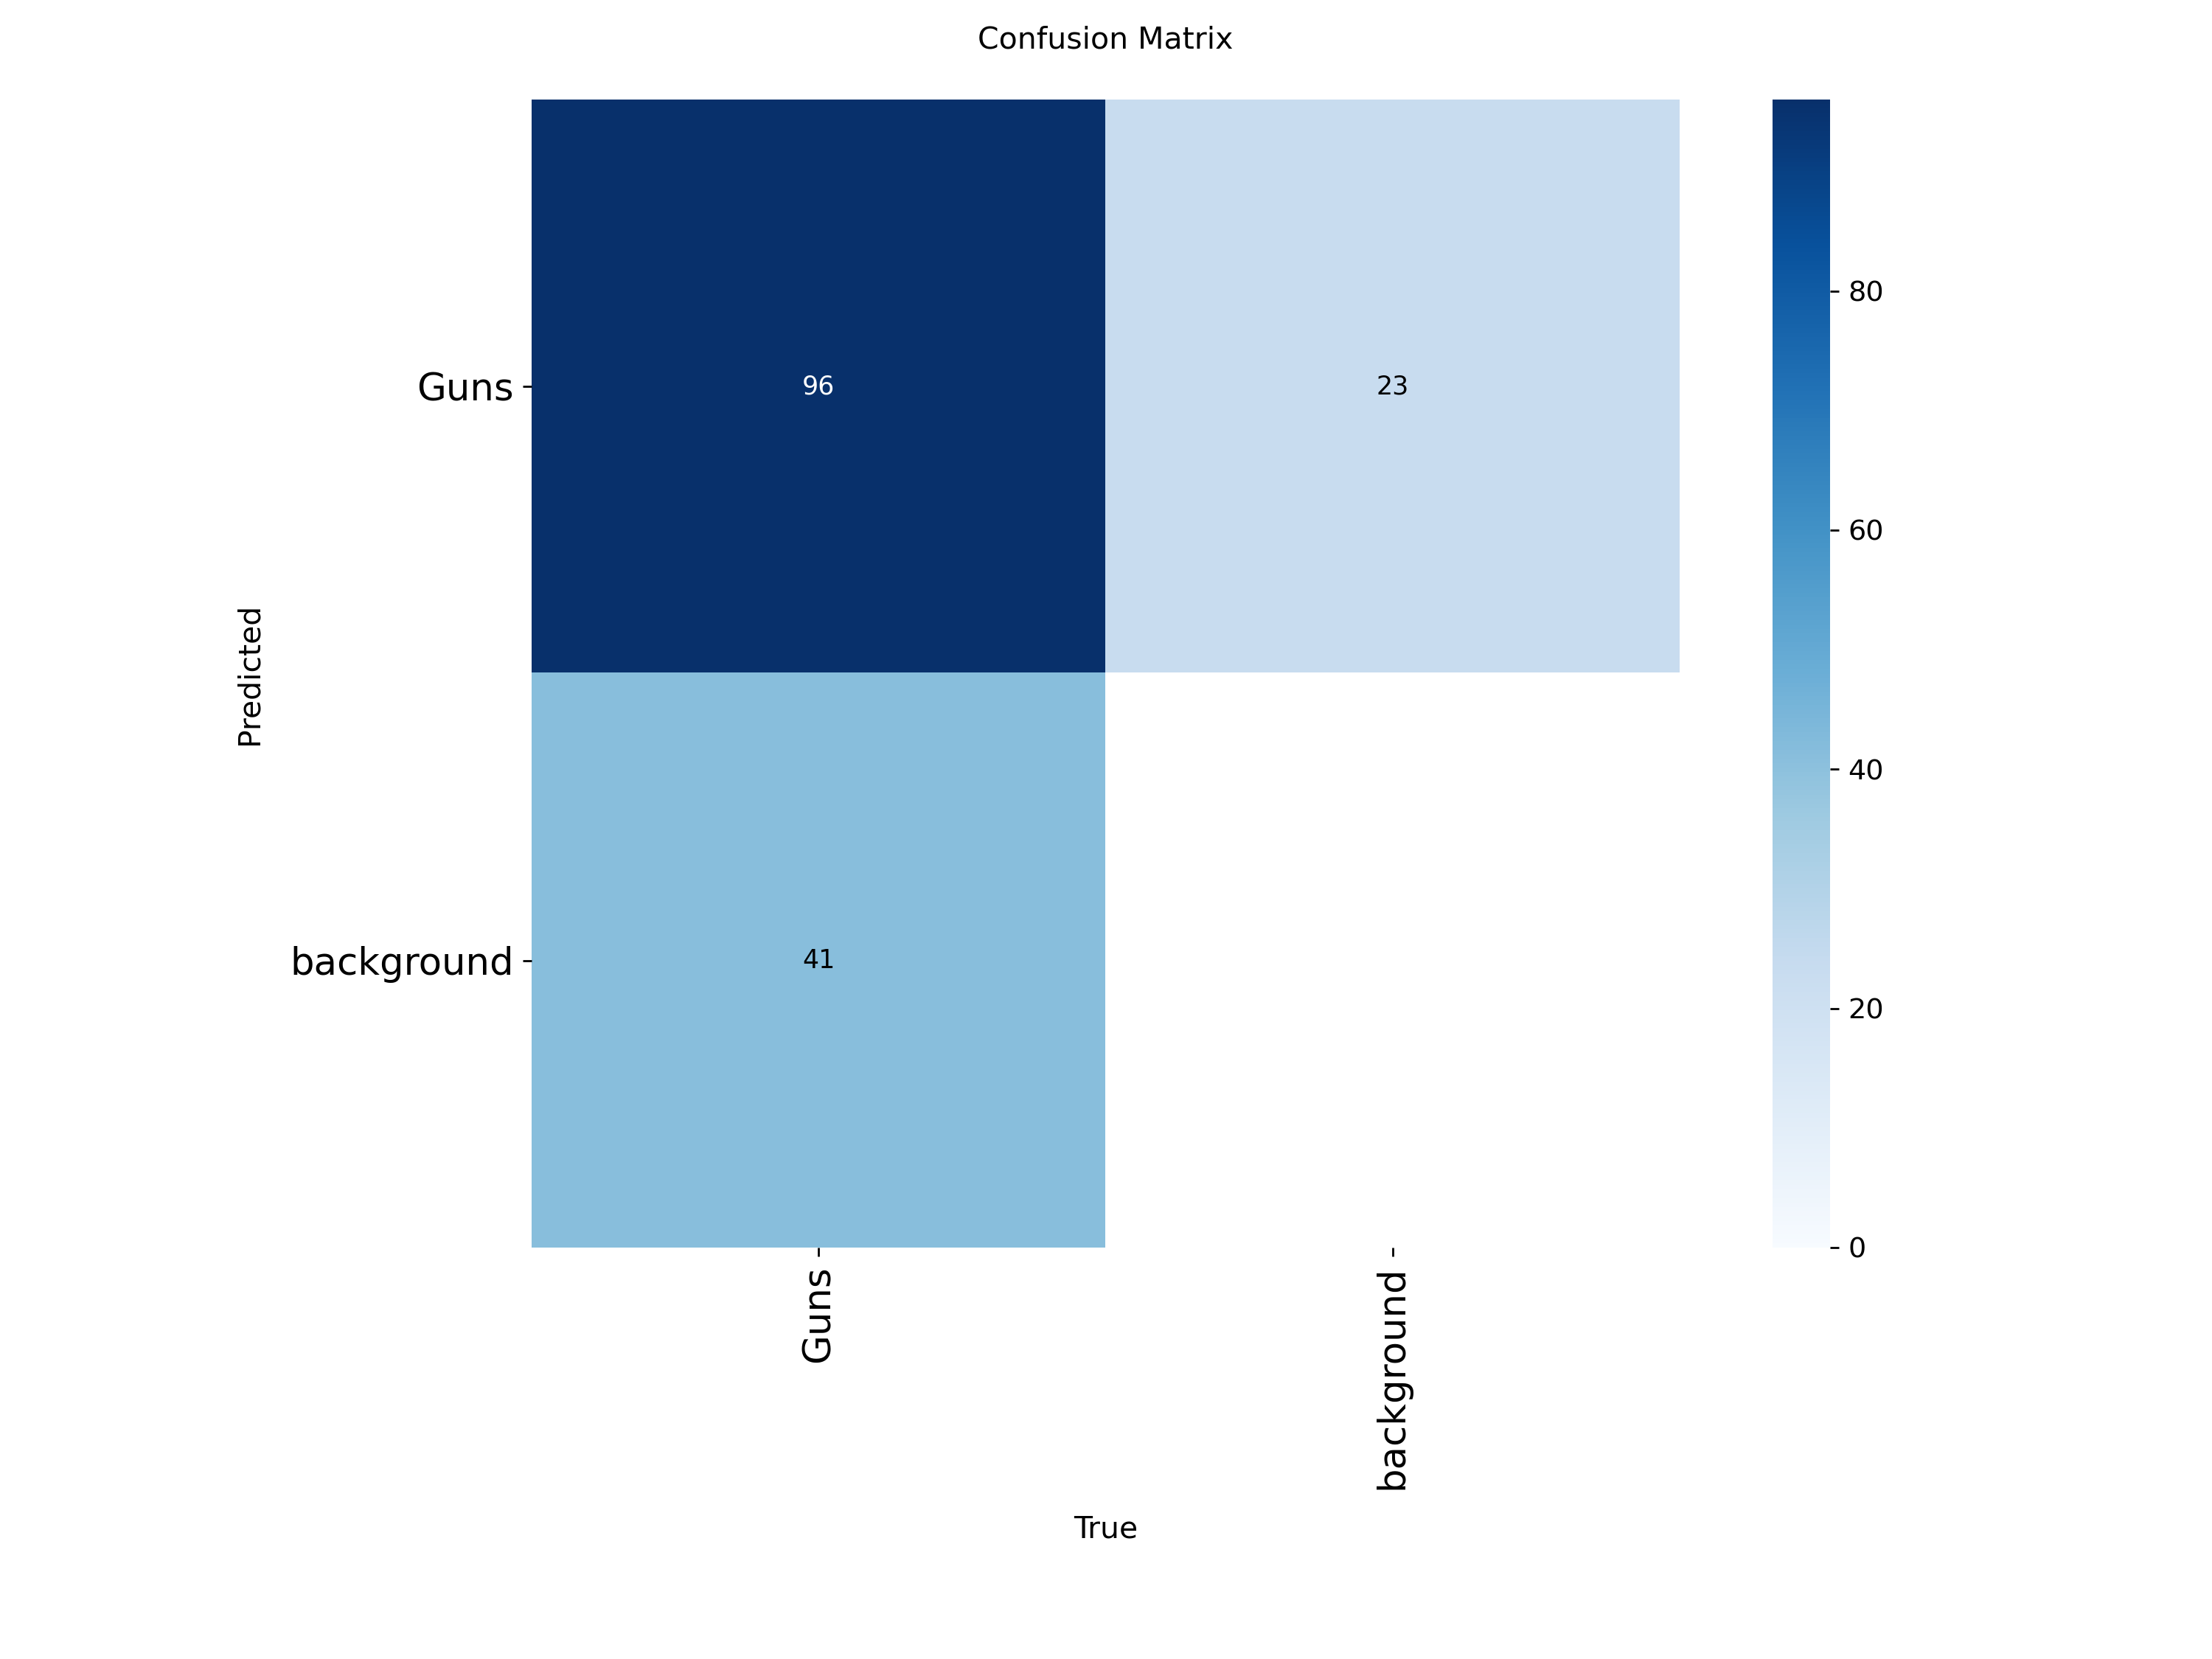

confusion_matrix.png


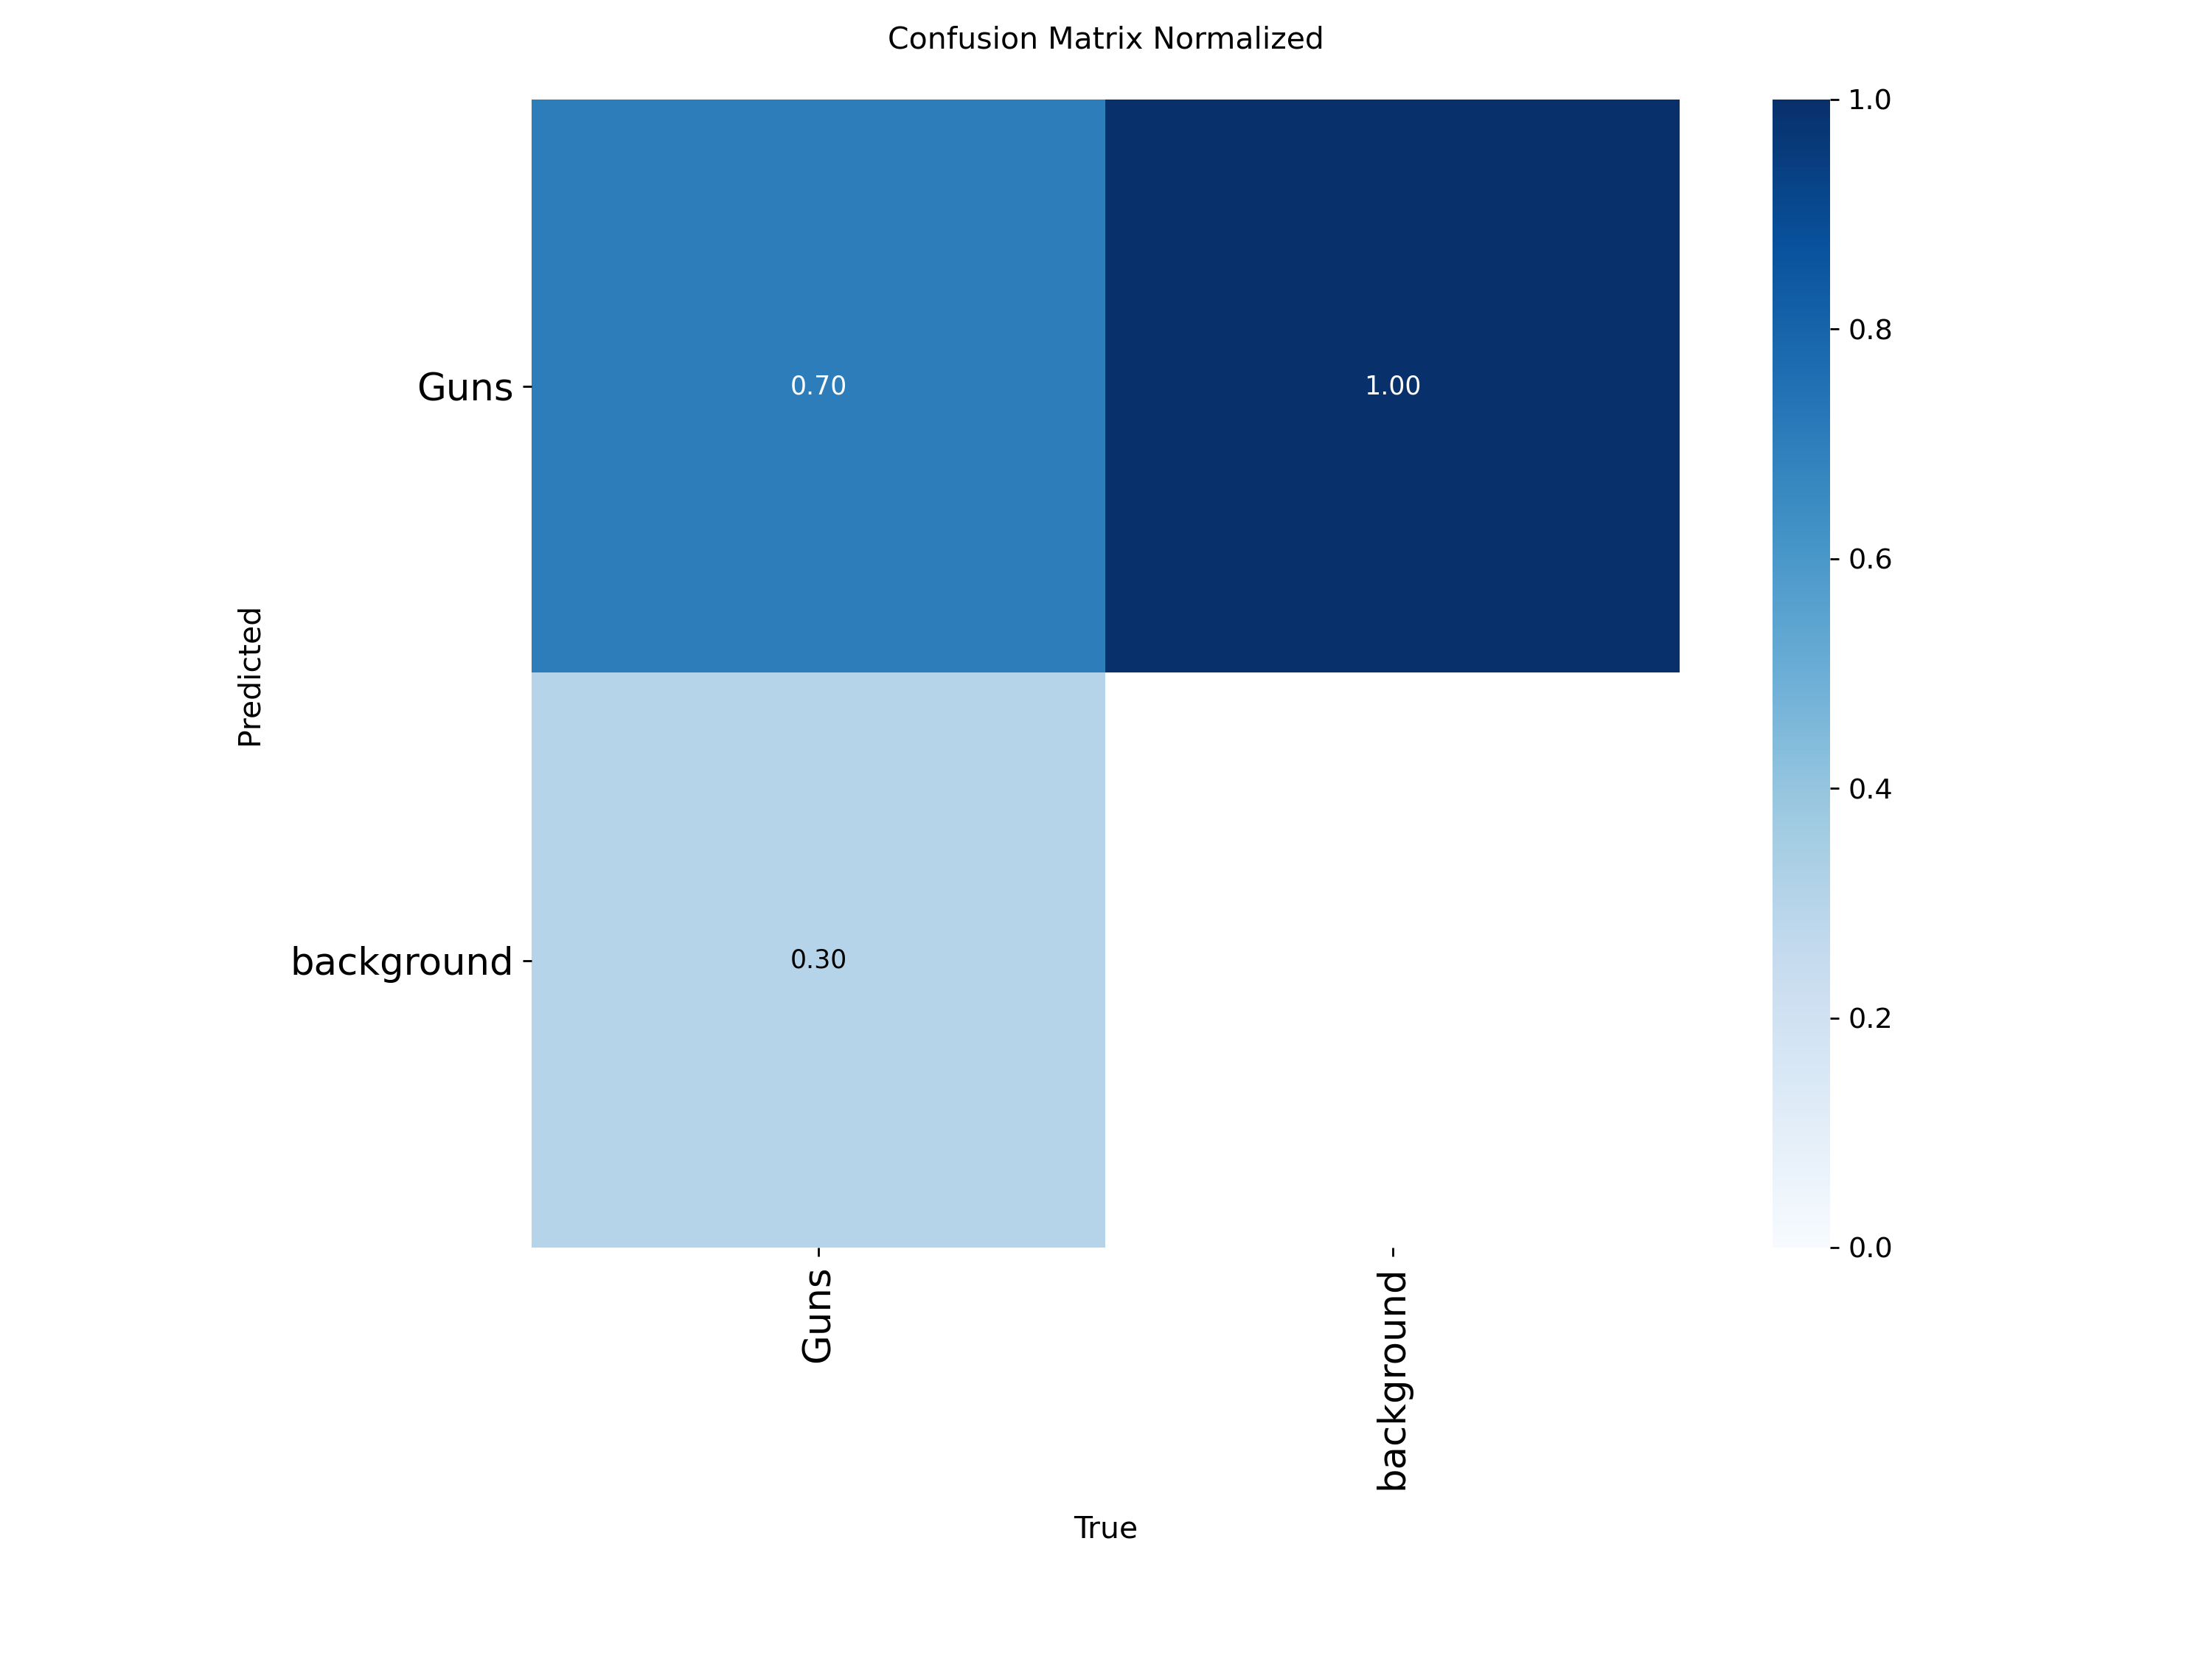

confusion_matrix_normalized.png


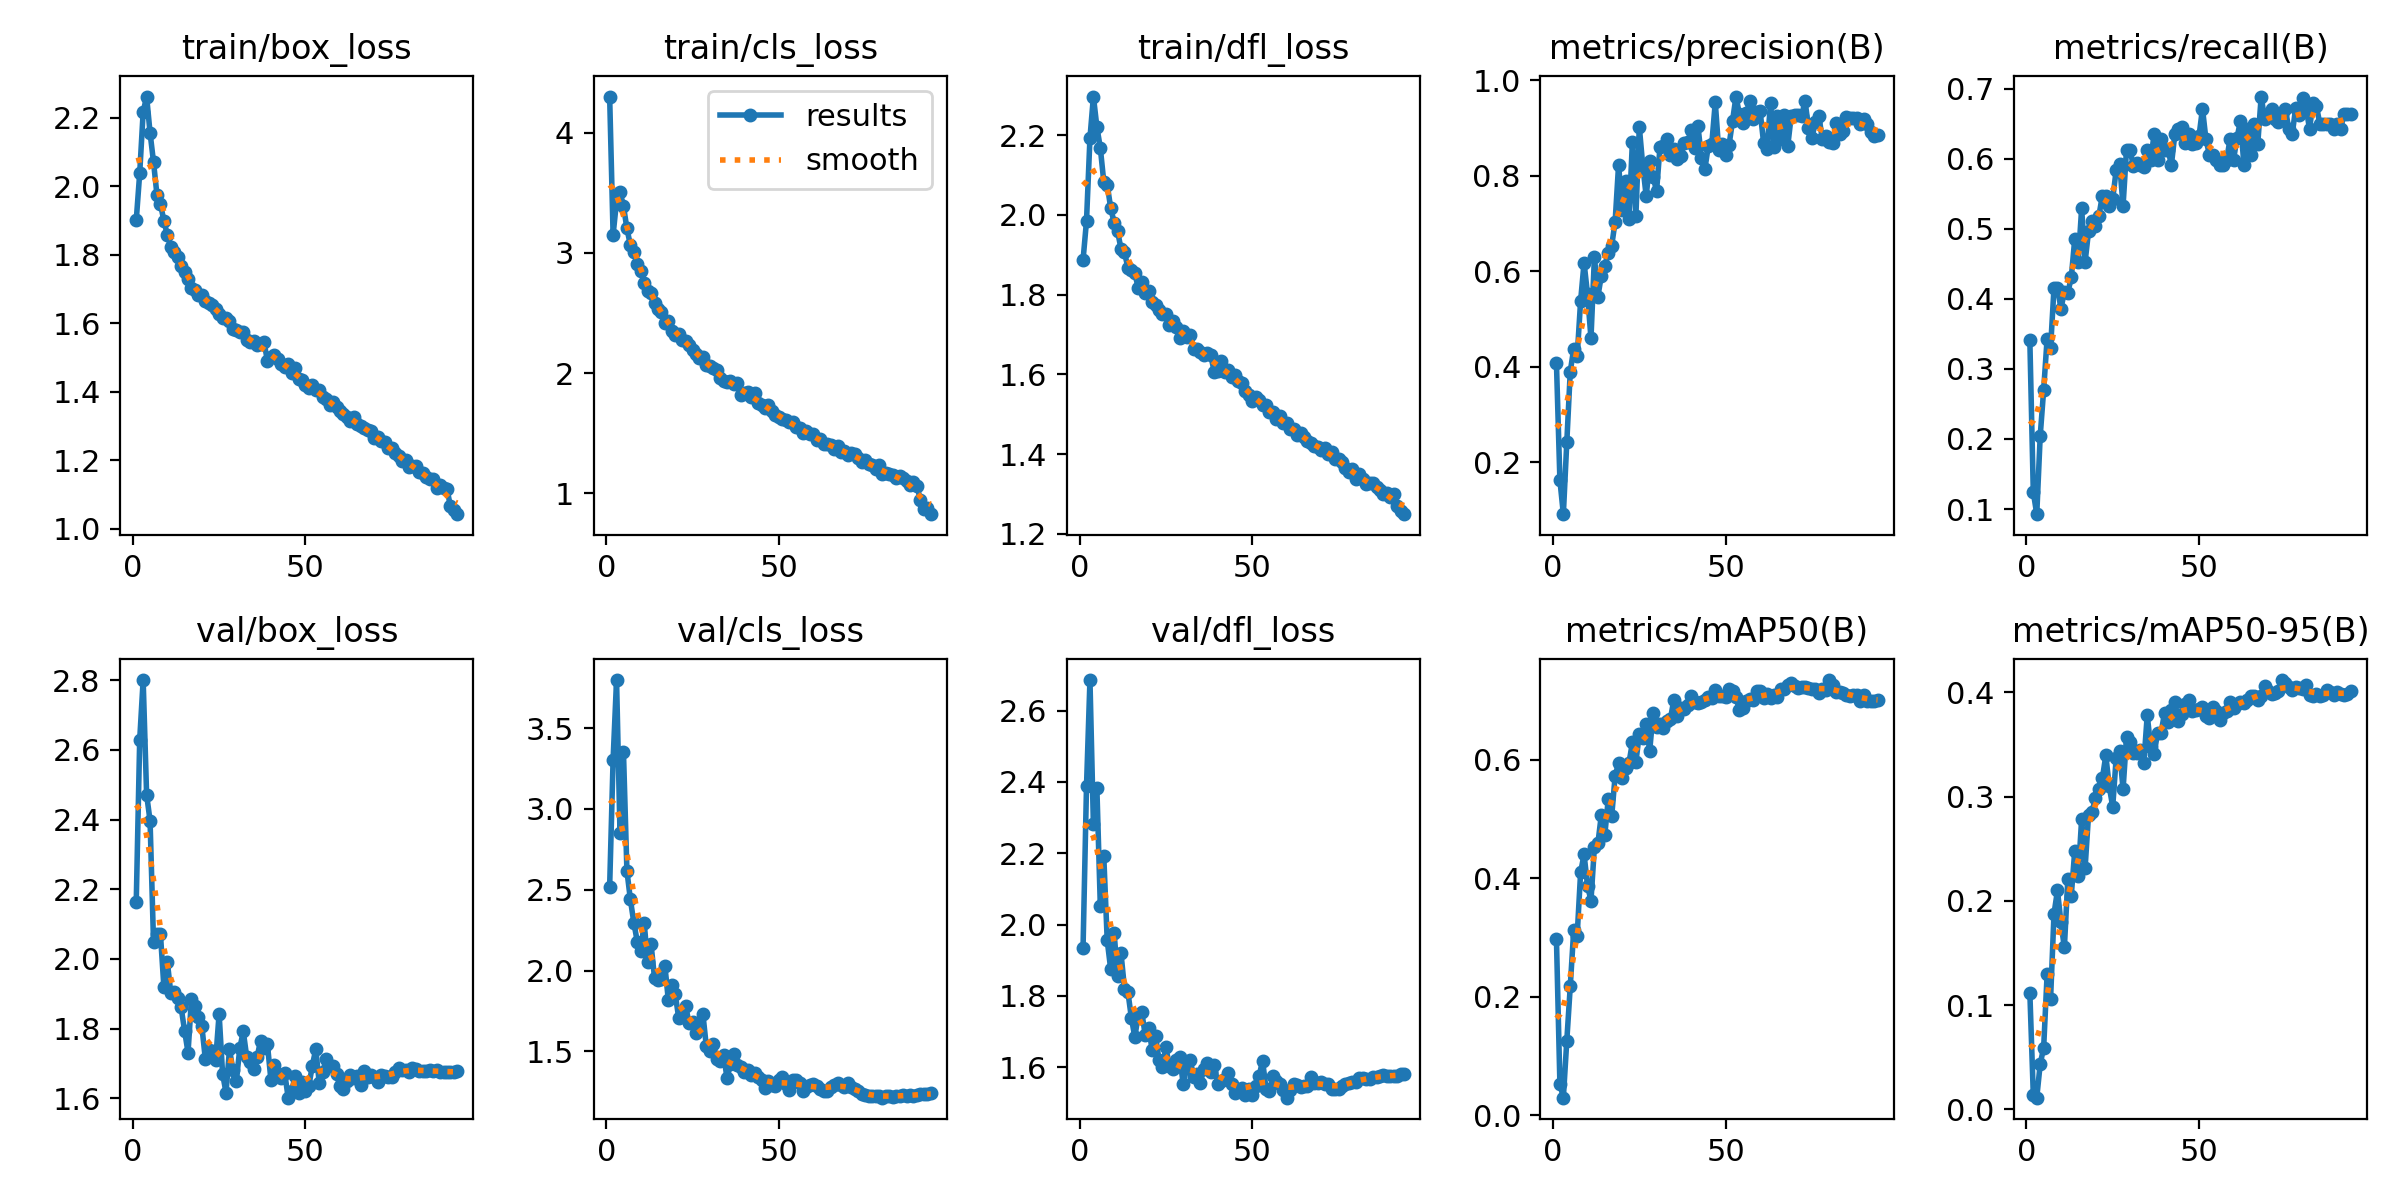

results.png


In [27]:
import os
from PIL import Image
from IPython.display import display

run_dir = Path("../runs/detect") / RUN_NAME
print(run_dir)

for file in os.listdir(run_dir):
    if file.endswith(".png"):
        display(Image.open(os.path.join(run_dir, file)))
        print(file)

In [28]:
def test_model_metrics(model_path, dataset_root, conf=0.28):
    model = YOLO(str(model_path))

    test_images_path = Path(dataset_root) / "test" / "images"
    test_labels_path = Path(dataset_root) / "test" / "labels"

    image_files = os.listdir(test_images_path)

    y_true = []
    y_pred = []
    latencies_ms = []

    for img_file in image_files:
        img_path = test_images_path / img_file
        label_path = test_labels_path / f"{Path(img_file).stem}.txt"

        has_object = label_path.exists() and label_path.stat().st_size > 0
        y_true.append(1 if has_object else 0)

        start = time.perf_counter()
        results = model.predict(str(img_path), conf=conf, verbose=False)
        end = time.perf_counter()

        latencies_ms.append((end - start) * 1000.0)

        boxes = results[0].boxes
        pred_has_object = boxes is not None and len(boxes) > 0
        y_pred.append(1 if pred_has_object else 0)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    avg_latency = mean(latencies_ms) if latencies_ms else 0.0
    std_latency = stdev(latencies_ms) if len(latencies_ms) > 1 else 0.0

    print("SYSTEM-LEVEL TEST METRICS")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Avg latency (ms): {avg_latency:.2f}")
    print(f"Std latency (ms): {std_latency:.2f}")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "avg_latency_ms": avg_latency,
        "std_latency_ms": std_latency
    }

In [29]:
system_metrics = test_model_metrics(best_model_path, dataset_path, conf=0.28)

SYSTEM-LEVEL TEST METRICS
Accuracy: 0.8333
Precision: 0.9773
Recall: 0.6935
F1 Score: 0.8113
Avg latency (ms): 11.83
Std latency (ms): 8.12


In [30]:
# Load trained model
model = YOLO(str(best_model_path))

# Export to ONNX
print("Exporting model to ONNX...")
onnx_path = model.export(format="onnx")

print("ONNX model saved at:", onnx_path)

Exporting model to ONNX...
Ultralytics 8.4.36  Python-3.12.0 torch-2.5.1+cu121 CPU (AMD Ryzen 7 7700 8-Core Processor)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from 'c:\Users\jandu\Documents\Capstone\Capstone-EdgeSafe\runs\detect\yolo11n_firearm_v1\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.2 MB)

ONNX: starting export with onnx 1.21.0 opset 19...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success  1.1s, saved as 'c:\Users\jandu\Documents\Capstone\Capstone-EdgeSafe\runs\detect\yolo11n_firearm_v1\weights\best.onnx' (10.1 MB)

Export complete (1.3s)
Results saved to C:\Users\jandu\Documents\Capstone\Capstone-EdgeSafe\runs\detect\yolo11n_firearm_v1\weights
Predict:         yolo predict task=detect model=c:\Users\jandu\Documents\Capstone\Capstone-EdgeSafe\runs\detect\yolo11n_firearm_v1\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=c:\Users\jandu\